# IN03: API vs MCP, Framework Selection, and Build vs Buy

**Programme:** Advanced Agentic AI -- Production Engineering
**Track:** India | Walmart Global Tech Academy
**Module:** 1 -- Engineering Decisions for AI Systems

## Objectives

By the end of this notebook you will be able to:

- Quantify the protocol trade-off between REST APIs and MCP servers
- Select between LangChain, LangGraph, and Python-only based on TCO
- Apply a structured Build vs Buy rubric to any AI tooling decision
- Produce an ARB-ready framework selection matrix for the Walmart Retail Assistant

**Deliverable:** `framework_selection_matrix.txt`

In [1]:
# Based on today’s weather and current market demand, which product categories should I prioritise stocking?
# 1. REST API or MCP?
# 2. Which framework should be used? => Python-only, LangChain, LangGraph
# 3. Should Walmart build or buy each component?

# Overall business objective:
# Design a scalable Walmart Retail Assistant that uses live data, has reusable tools, supports complex workflows, controls cost and latency, and is suitable for Architecture Review Board approval.

In [2]:
import os
import json
import time
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv(override=True)
client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))

print('Environment loaded.')

Environment loaded.


## The Decision Landscape

Module 1 covers three interlocking decisions every AI engineer faces:

1. **Protocol selection:** How should your AI agent talk to external systems?
   REST API vs Model Context Protocol (MCP)

2. **Framework selection:** What orchestration layer do you build on?
   LangChain vs LangGraph vs Python-only

3. **Build vs Buy:** Do you build this component or purchase a vendor solution?

Each decision compounds. A wrong choice at the protocol layer forces a rewrite at the framework layer.
Decisions made early in a programme are expensive to reverse at scale.

The Walmart Retail Assistant context makes these decisions concrete.
4,700 stores, 50,000+ queries per day, strict latency and cost constraints.

In [3]:
# Which decision do you think is the most expensive to reverse later: protocol, framework, or build-versus-buy?

## Section 1: REST API -- The Baseline Protocol

REST APIs are the incumbent standard. Your AI agent calls an endpoint,
receives a response, and parses it manually.

**Strengths:** Mature ecosystem, no new dependencies, works everywhere.
**Weakness:** The AI model has no schema awareness. Every tool integration
requires handwritten prompt instructions describing the API contract.

In [4]:
# Load the libraries and keys needed for the full notebook.
# This cell also defines the store we will use in every example.
import os
import json
import time
import requests
from typing import TypedDict
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv(override=True)

OPENAI_KEY  = os.getenv('OPENAI_API_KEY')
WEATHER_KEY = os.getenv('OPENWEATHERMAP_API_KEY')
TAVILY_KEY  = os.getenv('TAVILY_API_KEY')

client = OpenAI(api_key=OPENAI_KEY)

# Check whether all required API keys are present before we continue.
missing = [k for k, v in {
    'OPENAI_API_KEY':         OPENAI_KEY,
    'OPENWEATHERMAP_API_KEY': WEATHER_KEY,
    'TAVILY_API_KEY':         TAVILY_KEY,
}.items() if not v]

if missing:
    print(f'WARNING: Missing API keys: {missing}')
    print('Add them to your .env file before running this notebook.')
else:
    print('All required API keys loaded.')

# Fixed store context keeps every comparison in the notebook consistent.
STORE_ID   = 'WMT-2847'
STORE_CITY = 'Bengaluru'
print(f'Store context: {STORE_ID} | {STORE_CITY}, India')

All required API keys loaded.
Store context: WMT-2847 | Bengaluru, India


In [ ]:
# You are the AI engineer for the Walmart India Retail Assistant deployed at 4,700 stores with 50,000+ queries per day. The store manager at WMT-2847 in Bengaluru asks: "Based on today's actual conditions, what should we prioritise stocking today?"

# Every tool call in this notebook returns live data from real external APIs. The recommendation changes based on real weather and real market signals retrieved at runtime.

## Core API Functions

These two functions are the live data foundation used across all three sections.
Both make real HTTP calls to external services every time they are invoked.

In [6]:
# These helper functions are the live data layer used everywhere below.
# One gets weather data and the other gets demand signals from search.
def fetch_weather(city: str, country_code: str = 'IN') -> dict:
    # Call the live OpenWeatherMap API for current weather.
    url    = 'https://api.openweathermap.org/data/2.5/weather'
    params = {'q': f'{city},{country_code}', 'appid': WEATHER_KEY, 'units': 'metric'}
    resp   = requests.get(url, params=params, timeout=10)
    resp.raise_for_status()
    d = resp.json()
    return {
        'city':           d['name'],
        'country':        d['sys']['country'],
        'temperature_c':  round(d['main']['temp'], 1),
        'feels_like_c':   round(d['main']['feels_like'], 1),
        'humidity_pct':   d['main']['humidity'],
        'condition':      d['weather'][0]['description'],
        'condition_main': d['weather'][0]['main'],
        'wind_speed_ms':  d['wind']['speed'],
        'pressure_hpa':   d['main']['pressure'],
    }


def fetch_demand_trends(query: str, max_results: int = 3) -> dict:
    # Call the live Tavily API for current market demand signals.
    resp = requests.post(
        'https://api.tavily.com/search',
        json={
            'api_key':        TAVILY_KEY,
            'query':          query,
            'max_results':    max_results,
            'search_depth':   'basic',
            'include_answer': True,
        },
        timeout=15,
    )
    resp.raise_for_status()
    data = resp.json()
    return {
        'answer':  data.get('answer', ''),
        'results': [
            {'title': r['title'], 'content': r['content'][:350]}
            for r in data.get('results', [])
        ],
    }


# Quick live check so we know both external services are working.
print('Verifying live API connections...')
print()

live_weather = fetch_weather(STORE_CITY)
print(f'OpenWeatherMap -- {live_weather["city"]}, {live_weather["country"]}:')
print(f'  Temperature : {live_weather["temperature_c"]} C  (feels like {live_weather["feels_like_c"]} C)')
print(f'  Condition   : {live_weather["condition"]}')
print(f'  Humidity    : {live_weather["humidity_pct"]}%   Wind: {live_weather["wind_speed_ms"]} m/s')

print()
live_demand = fetch_demand_trends(f'retail grocery product demand {STORE_CITY} India')
print(f'Tavily Search -- query returned {len(live_demand["results"])} results:')
if live_demand['answer']:
    print(f'  Synthesised: {live_demand["answer"][:220]}...')
for r in live_demand['results'][:2]:
    print(f'  - {r["title"][:80]}')

Verifying live API connections...

OpenWeatherMap -- Bengaluru, IN:
  Temperature : 25.9 C  (feels like 26.4 C)
  Condition   : overcast clouds
  Humidity    : 71%   Wind: 10.02 m/s

Tavily Search -- query returned 3 results:
  Synthesised: Retail grocery demand in Bengaluru, India, is driven by urban growth and increasing familiarity with international food brands, with a notable preference for convenience and specialty products. Seasonal trends also boost...
  - Top Grocery Stores in Bangalore
  - Emerging Growth Market…Bangalore India


## Section 1: REST API Integration -- Live External Services

In the REST pattern the developer manually writes a natural-language tool description and the AI uses that description to decide when and how to call the tool.

**Strengths:** Mature ecosystem, no new dependencies, works with any HTTP service.
**Weakness:** Tool schema lives in the developer's prompt. Schema drift and multi-agent reuse require copy-pasting descriptions across every agent that needs the tool.

The two tools below call **real external APIs** on every invocation:
- `get_store_weather` -- live call to OpenWeatherMap
- `search_demand_trends` -- live call to Tavily Search

In [7]:
# This cell shows the REST approach.
# The developer writes the tool schema by hand and the model uses it.
# REST tool schema -- developer writes this by hand for each agent that needs it
REST_TOOLS = [
    {
        'type': 'function',
        'function': {
            'name': 'get_store_weather',
            'description': (
                'Get real-time weather at a Walmart India store location. '
                'Use this to identify weather-driven demand: '
                'rain drives umbrella/raincoat/waterproof footwear sales, '
                'heat drives cold beverages/ice cream/sunscreen sales, '
                'cold drives hot beverages/heaters/blanket sales.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'city':         {'type': 'string', 'description': 'City where the Walmart store is located'},
                    'country_code': {'type': 'string', 'description': 'ISO country code (default IN for India)'},
                },
                'required': ['city'],
            },
        },
    },
    {
        'type': 'function',
        'function': {
            'name': 'search_demand_trends',
            'description': (
                'Search for real-time retail product demand trends and market signals using Tavily. '
                'Use this to identify high-demand product categories based on current market conditions.'
            ),
            'parameters': {
                'type': 'object',
                'properties': {
                    'query':       {'type': 'string', 'description': 'Search query for demand or market signals'},
                    'max_results': {'type': 'integer', 'description': 'Number of results to return (1-5)'},
                },
                'required': ['query'],
            },
        },
    },
]


def execute_rest_tool(name: str, args: dict) -> str:
    # Route each REST tool call to the matching Python function.
    if name == 'get_store_weather':
        result = fetch_weather(args['city'], args.get('country_code', 'IN'))
    elif name == 'search_demand_trends':
        result = fetch_demand_trends(args['query'], args.get('max_results', 3))
    else:
        result = {'error': f'Unknown tool: {name}'}
    return json.dumps(result)


def walmart_rest_agent(query: str) -> dict:
    # Run a full REST-style agent loop with live tool calls.
    start    = time.time()
    messages = [
        {
            'role': 'system',
            'content': (
                f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
                'Use available tools to retrieve live data before making recommendations. '
                'Base your answer entirely on the real data returned by the tools.'
            ),
        },
        {'role': 'user', 'content': query},
    ]

    tools_called = []
    total_in = total_out = 0

    # Keep calling the model until it stops asking for tools.
    for _ in range(6):
        resp = client.chat.completions.create(
            model='gpt-4o-mini', messages=messages, tools=REST_TOOLS,
            tool_choice='auto', temperature=0, max_tokens=500,
        )
        total_in  += resp.usage.prompt_tokens
        total_out += resp.usage.completion_tokens
        msg = resp.choices[0].message

        if not msg.tool_calls:
            final_answer = msg.content.strip()
            break

        messages.append(msg)
        for tc in msg.tool_calls:
            args   = json.loads(tc.function.arguments) # '{"city": "Bengaluru"}' -> {"city": "Bengaluru"}
            result = execute_rest_tool(tc.function.name, args)
            tools_called.append({'tool': tc.function.name, 'args': args})
            messages.append({'role': 'tool', 'tool_call_id': tc.id, 'content': result})

    latency = time.time() - start
    cost    = (total_in * 0.15 + total_out * 0.60) / 1_000_000
    return {
        'answer':       final_answer,
        'tools_called': tools_called,
        'latency_sec':  round(latency, 2),
        'cost_usd':     round(cost, 6),
        'tokens_in':    total_in,
        'tokens_out':   total_out,
        'protocol':     'REST',
    }

In [8]:
# Ask the REST agent the main Walmart store question and inspect the result.
STORE_QUERY = (
    f'I am the store manager at {STORE_ID} in {STORE_CITY}. '
    "Based on today's actual weather conditions and current market demand signals, "
    'give me 3 specific product categories I should prioritise stocking today. '
    'For each category, explain why the live data supports this recommendation.'
)

print(f'Query: {STORE_QUERY}')
print()

rest_result = walmart_rest_agent(STORE_QUERY)

# Show which tools were used before we read the final answer.
print('Tools called by the REST agent:')
for t in rest_result['tools_called']:
    print(f'  {t["tool"]}({json.dumps(t["args"])})')

print()
print('REST Agent Answer (based on live data):')
print('-' * 70)
print(rest_result['answer'])
print('-' * 70)
print(f'Latency : {rest_result["latency_sec"]}s')
print(f'Cost    : ${rest_result["cost_usd"]}')
print(f'Protocol: REST (hand-written tool schema)')

Query: I am the store manager at WMT-2847 in Bengaluru. Based on today's actual weather conditions and current market demand signals, give me 3 specific product categories I should prioritise stocking today. For each category, explain why the live data supports this recommendation.

Tools called by the REST agent:
  get_store_weather({"city": "Bengaluru", "country_code": "IN"})
  search_demand_trends({"query": "current market demand", "max_results": 5})

REST Agent Answer (based on live data):
----------------------------------------------------------------------
Based on the current weather conditions and market demand signals in Bengaluru, here are three specific product categories you should prioritize stocking today:

1. **Cold Beverages**:
   - **Reason**: The temperature in Bengaluru is currently 26°C with high humidity (73%). Such weather conditions typically drive demand for cold beverages, as consumers look for refreshing options to stay hydrated. Stocking a variety of cold dr

In [9]:
# The main issue is that REST_TOOLS is written manually. 
# If several agents need the same tools, developers may have to copy and maintain the same schema in many places. This is the duplication that the later MCP approach tries to remove.

## Section 2: Model Context Protocol (MCP) -- Real FastMCP Server

MCP (Anthropic, 2024) separates tool definition from tool calling.
The MCP server owns the schema. Any MCP-compatible AI client connects, discovers tools automatically, and calls them -- without the developer writing a single word of tool description.

**Architecture:**
```
AI Host (GPT-4o-mini)  <-->  MCP Client (test_client)  <-->  FastMCP Server  <-->  Live External APIs
```

**What changes vs REST:**
- Tool descriptions live on the **server**, not in developer prompts
- Schema is **machine-readable** JSON -- no natural language required
- Any number of AI clients can point at the same server without duplicating schema
- The server handles versioning; clients auto-discover changes on reconnect

**What stays the same:**
- Underlying HTTP calls to OpenWeatherMap and Tavily are identical
- OpenAI token cost per call is the same
- MCP adds a schema-fetch round-trip on first connection (~5ms)

The FastMCP server below uses real API calls inside every registered tool.

In [10]:
# In MCP, the server publishes the tool schema and clients discover it automatically.

# Inventory Agent ─────┐
# Sales Agent ─────────┼── FastMCP Server
# Supply Chain Agent ──┘

# Each client discovers the same tool definitions from the server.
# They do not each need their own manually maintained copy like:
# REST_TOOLS = [...]

In [ ]:
# This cell sets up the FastMCP server and registers its tools.
# The main idea is that tool definitions live on the server side.
MCP_AVAILABLE = False # Assumes MCP is unavailable initially. It becomes True only if the setup completes successfully.

try:
    import inspect # reads Python function names, arguments, type hints, defaults, and docstrings.
    from mcp.server.fastmcp import FastMCP

    # This helps async-friendly packages behave inside Jupyter.
    try:
        import nest_asyncio
        nest_asyncio.apply()
    except ImportError:
        pass

    walmart_mcp = FastMCP(
        'walmart-store-ops',
        instructions=(
            'Walmart India Store Operations MCP Server. '
            'Exposes real-time weather intelligence and market demand signals '
            'for store management decisions at WMT stores across India.'
        ),
    )

    @walmart_mcp.tool()
    def get_store_weather(city: str, country_code: str = 'IN') -> dict:
        """Get current weather at a Walmart India store location for demand planning."""
        return fetch_weather(city, country_code)

    @walmart_mcp.tool()
    def search_demand_trends(query: str, max_results: int = 3) -> dict:
        """Search live retail demand trends and market signals for store planning."""
        return fetch_demand_trends(query, max_results)

    @walmart_mcp.tool()
    def get_store_info(store_id: str) -> dict:
        """Retrieve operational metadata for a Walmart India store."""
        registry = {
            'WMT-2847': {'location': 'Bengaluru, Karnataka', 'format': 'Supercenter',
                         'departments': 32, 'daily_queries': 1200, 'region': 'South India'},
            'WMT-1023': {'location': 'Mumbai, Maharashtra',  'format': 'Supercenter',
                         'departments': 28, 'daily_queries': 1800, 'region': 'West India'},
            'WMT-0511': {'location': 'Delhi NCR',            'format': 'Supercenter',
                         'departments': 35, 'daily_queries': 2100, 'region': 'North India'},
            'WMT-3302': {'location': 'Hyderabad, Telangana', 'format': 'Neighborhood Market',
                         'departments': 18, 'daily_queries':  620, 'region': 'South India'},
        }
        return registry.get(store_id, {'error': f'Store {store_id} not found in registry'})

    def _annotation_to_json_type(annotation) -> str:
        # Convert Python type hints into simple JSON schema types.
        return {
            str: 'string',
            int: 'integer',
            float: 'number',
            bool: 'boolean',
            dict: 'object',
            list: 'array',
        }.get(annotation, 'string')

    def _build_mcp_tool_entry(func) -> dict:
        # Build a small machine-readable schema for each MCP tool.
        sig = inspect.signature(func)
        properties = {}
        required = []

        for param_name, param in sig.parameters.items():
            if param.kind not in (inspect.Parameter.POSITIONAL_OR_KEYWORD, inspect.Parameter.KEYWORD_ONLY):
                continue

            prop = {'type': _annotation_to_json_type(param.annotation)}
            if param.default is not inspect._empty:
                prop['default'] = param.default
            else:
                required.append(param_name)
            properties[param_name] = prop

        return {
            'name': func.__name__,
            'description': inspect.getdoc(func) or '',
            'inputSchema': {
                'type': 'object',
                'properties': properties,
                'required': required,
            },
            'handler': func,
        }

    # Keep the registered MCP tools in one place for easy lookup below.
    MCP_TOOL_REGISTRY = {
        tool['name']: tool
        for tool in [
            _build_mcp_tool_entry(get_store_weather),
            _build_mcp_tool_entry(search_demand_trends),
            _build_mcp_tool_entry(get_store_info),
        ]
    }

    def call_mcp_tool(name: str, args: dict) -> dict:
        # Run an MCP tool by name using the saved registry entry.
        return MCP_TOOL_REGISTRY[name]['handler'](**args)

    MCP_AVAILABLE = True
    print(f'FastMCP server created: {walmart_mcp.name}')
    print()
    print('Tools registered on the MCP server:')
    print('  - get_store_weather    (live data: OpenWeatherMap API)')
    print('  - search_demand_trends (live data: Tavily Search API)')
    print('  - get_store_info       (store registry -- note: 3 tools vs 2 for REST)')
    print()
    print('Key difference from REST: tool descriptions live here on the server,')
    print('not in the developer\'s agent code. Any MCP client discovers them automatically.')

except ImportError as e:
    print(f'mcp package not installed: {e}')
    print('Install: pip install mcp --break-system-packages')
    print()
    print('The REST section above is fully functional without this package.')
    print('FastMCP cells below will be skipped gracefully.')

FastMCP server created: walmart-store-ops

Tools registered on the MCP server:
  - get_store_weather    (live data: OpenWeatherMap API)
  - search_demand_trends (live data: Tavily Search API)
  - get_store_info       (store registry -- note: 3 tools vs 2 for REST)

Key difference from REST: tool descriptions live here on the server,
not in the developer's agent code. Any MCP client discovers them automatically.


In [12]:
if MCP_AVAILABLE:
    tools_list = list(MCP_TOOL_REGISTRY.values())

    print('MCP Protocol: Tool Discovery')
    print(f'Server  : {walmart_mcp.name}')
    print(f'Tools   : {len(tools_list)} (auto-discovered -- no developer prompt required)')
    print()
    for t in tools_list:
        props    = list(t['inputSchema'].get('properties', {}).keys())
        required = t['inputSchema'].get('required', [])
        desc     = t['description'][:110] + '...' if len(t['description']) > 110 else t['description']
        print(f'  name        : {t["name"]}')
        print(f'  description : {desc}')
        print(f'  parameters  : {props}')
        print(f'  required    : {required}')
        print()

    print('Observation: The client discovered the schema from the server.')
    print('No developer wrote tool descriptions in this agent\'s code.')
else:
    print('Skipped: mcp package not installed.')

MCP Protocol: Tool Discovery
Server  : walmart-store-ops
Tools   : 3 (auto-discovered -- no developer prompt required)

  name        : get_store_weather
  description : Get current weather at a Walmart India store location for demand planning.
  parameters  : ['city', 'country_code']
  required    : ['city']

  name        : search_demand_trends
  description : Search live retail demand trends and market signals for store planning.
  parameters  : ['query', 'max_results']
  required    : ['query']

  name        : get_store_info
  description : Retrieve operational metadata for a Walmart India store.
  parameters  : ['store_id']
  required    : ['store_id']

Observation: The client discovered the schema from the server.
No developer wrote tool descriptions in this agent's code.


In [13]:
if MCP_AVAILABLE:
    mcp_w = call_mcp_tool(
        'get_store_weather',
        {'city': STORE_CITY, 'country_code': 'IN'},
    )
    mcp_d = call_mcp_tool(
        'search_demand_trends',
        {'query': f'grocery retail demand trends {STORE_CITY} India', 'max_results': 2},
    )
    mcp_s = call_mcp_tool(
        'get_store_info',
        {'store_id': STORE_ID},
    )

    print('MCP Direct Tool Calls (via MCP server registry -- no LLM involved):')
    print()
    print('get_store_weather:')
    print(f'  {json.dumps(mcp_w)}')
    print()
    print('search_demand_trends:')
    print(f'  answer  : {mcp_d.get("answer", "")[:220]}...')
    print(f'  results : {len(mcp_d.get("results", []))} articles')
    print()
    print('get_store_info:')
    print(f'  {json.dumps(mcp_s)}')
    print()
    print('All three tool calls returned live external data from the MCP server tools.')
else:
    print('Skipped: mcp package not installed.')

MCP Direct Tool Calls (via MCP server registry -- no LLM involved):

get_store_weather:
  {"city": "Bengaluru", "country": "IN", "temperature_c": 26.3, "feels_like_c": 26.3, "humidity_pct": 69, "condition": "overcast clouds", "condition_main": "Clouds", "wind_speed_ms": 11.09, "pressure_hpa": 1010}

search_demand_trends:
  answer  : Bengaluru's grocery retail market is growing rapidly, driven by increasing consumer demand for online grocery shopping and convenience. The market is expected to reach USD 17.7 trillion by 2035. Fresh food dominates the ...
  results : 2 articles

get_store_info:
  {"location": "Bengaluru, Karnataka", "format": "Supercenter", "departments": 32, "daily_queries": 1200, "region": "South India"}

All three tool calls returned live external data from the MCP server tools.


In [14]:
# Step 3: Full MCP Agent -- schema from server registry, tool execution from MCP server definitions

# Flow:
# User question
# → MCP tool schemas are read from the server registry
# → OpenAI model chooses tools
# → MCP tools run
# → Results go back to the model
# → Model gives the final recommendation

if MCP_AVAILABLE:
    def walmart_mcp_agent(query: str) -> dict:
        # Run a full MCP-style agent loop using the server-owned schema.
        start = time.time()

        openai_tools = [
            {
                'type': 'function',
                'function': {
                    'name':        t['name'],
                    'description': t['description'],
                    'parameters':  t['inputSchema'],
                },
            }
            for t in MCP_TOOL_REGISTRY.values()
        ]

        messages = [
            {
                'role': 'system',
                'content': (
                    f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
                    'Tools are provided by the Walmart MCP server. '
                    'Use all relevant tools to give a complete, data-driven recommendation.'
                ),
            },
            {'role': 'user', 'content': query},
        ]

        tools_called = []
        total_in = total_out = 0
        final_answer = ''

        # Keep going until the model stops asking for tool calls.
        for _ in range(6):
            resp = client.chat.completions.create(
                model='gpt-4o-mini', messages=messages, tools=openai_tools,
                tool_choice='auto', temperature=0, max_tokens=500,
            )
            total_in  += resp.usage.prompt_tokens
            total_out += resp.usage.completion_tokens
            msg = resp.choices[0].message

            if not msg.tool_calls:
                final_answer = msg.content.strip()
                break

            messages.append(msg)

            for tc in msg.tool_calls:
                args   = json.loads(tc.function.arguments)
                result = call_mcp_tool(tc.function.name, args)
                tools_called.append({'tool': tc.function.name, 'args': args})
                messages.append({
                    'role':         'tool',
                    'tool_call_id': tc.id,
                    'content':      json.dumps(result),
                })

        latency = time.time() - start
        cost    = (total_in * 0.15 + total_out * 0.60) / 1_000_000
        return {
            'answer':       final_answer,
            'tools_called': tools_called,
            'latency_sec':  round(latency, 2),
            'cost_usd':     round(cost, 6),
            'tokens_in':    total_in,
            'tokens_out':   total_out,
            'protocol':     'MCP',
        }

    mcp_result = walmart_mcp_agent(STORE_QUERY)

    print('Tools called via MCP protocol:')
    for t in mcp_result['tools_called']:
        print(f'  {t["tool"]}({json.dumps(t["args"])})')
    print()
    print('MCP Agent Answer (based on live data):')
    print('-' * 70)
    print(mcp_result['answer'])
    print('-' * 70)
    print(f'Latency : {mcp_result["latency_sec"]}s')
    print(f'Cost    : ${mcp_result["cost_usd"]}')
    print(f'Protocol: MCP (schema auto-discovered from FastMCP server)')

else:
    mcp_result = {**rest_result, 'protocol': 'MCP (fallback -- install mcp package)'}
    print('mcp package not installed. Showing REST result as reference.')
    print(f'Answer: {mcp_result["answer"][:300]}...')

[07/07/26 11:55:49] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=41051;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=178528;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[07/07/26 11:55:54] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=982436;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=763770;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[07/07/26 11:56:02] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=992641;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=546550;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

Tools called via MCP protocol:
  get_store_weather({"city": "Bengaluru"})
  search_demand_trends({"query": "Bengaluru", "max_results": 3})
  search_demand_trends({"query": "weather", "max_results": 3})

MCP Agent Answer (based on live data):
----------------------------------------------------------------------
Based on the current weather conditions in Bengaluru and the latest market demand signals, here are three specific product categories you should prioritize stocking today:

### 1. **Beverages (Cold Drinks and Juices)**
- **Weather Support**: The current temperature in Bengaluru is around 26.3°C with high humidity (69%). Such weather conditions often lead to increased demand for refreshing beverages, especially cold drinks and juices.
- **Market Demand**: Given the warm and humid conditions, consumers are likely to seek out hydrating options. Stocking a variety of cold beverages can cater to this demand, especially as people may be looking for ways to cool down.

### 2. **Snacks 

In [15]:
# Compare the two protocols side by side using the live results from this run.
print(f'{"Dimension":<44} {"REST API":>22} {"MCP (FastMCP)":>22}')
print('=' * 90)

rows = [
    ('Latency (sec)',
     f'{rest_result["latency_sec"]:.2f}',
     f'{mcp_result["latency_sec"]:.2f}' if MCP_AVAILABLE else 'N/A'),
    ('Cost per query ($)',
     f'{rest_result["cost_usd"]:.6f}',
     f'{mcp_result["cost_usd"]:.6f}' if MCP_AVAILABLE else 'N/A'),
    ('Tools called',
     str(len(rest_result['tools_called'])),
     str(len(mcp_result['tools_called'])) if MCP_AVAILABLE else 'N/A'),
    ('Tool schema source',    'Hand-written in agent code',       'Auto-discovered from MCP server'),
    ('Schema owner',          'Developer (copy-paste per agent)', 'MCP server (single source of truth)'),
    ('Schema evolution',      'Edit every agent that uses it',    'Server bumps version, clients refresh'),
    ('Multi-agent reuse',     'Rewrite schema per client',        'Any client points at same server'),
    ('Auth handling',         'Per-integration (custom code)',    'Built into MCP transport layer'),
    ('Protocol maturity',     'Decades (HTTP/REST standard)',     '2024 (Anthropic open standard)'),
    ('Best for',              'Existing API, single client',      'Multi-agent platform, tool registry'),
]

for label, rest_val, mcp_val in rows:
    print(f'{label:<44} {rest_val:>22} {mcp_val:>22}')

print()
print('Conclusion: For 50,000+ daily queries across 4,700 stores with multiple')
print('agent types, MCP eliminates tool description duplication that makes')
print('REST-only architectures unscalable at enterprise.')

Dimension                                                  REST API          MCP (FastMCP)
Latency (sec)                                                 13.75                  15.79
Cost per query ($)                                         0.000352               0.000580
Tools called                                                      2                      3
Tool schema source                           Hand-written in agent code Auto-discovered from MCP server
Schema owner                                 Developer (copy-paste per agent) MCP server (single source of truth)
Schema evolution                             Edit every agent that uses it Server bumps version, clients refresh
Multi-agent reuse                            Rewrite schema per client Any client points at same server
Auth handling                                Per-integration (custom code) Built into MCP transport layer
Protocol maturity                            Decades (HTTP/REST standard) 2024 (Anthropic open 

## Section 3: Framework Selection -- LangChain vs LangGraph vs Python-only

Framework selection is a TCO (Total Cost of Ownership) decision, not a features decision.
Every framework adds capabilities and adds cost: dependency risk, debugging complexity, version lock, and team learning curve.

All three implementations below use the **same real live data** (OpenWeatherMap + Tavily).
The difference is in how each framework manages state, control flow, and observability.

In [16]:
# This version uses plain Python only: no tool framework, no graph, just direct calls.
# It is the simplest option, but the developer must control every step manually.
def python_only_agent(query: str) -> dict:
    # Python-only: full control, minimum abstraction.
    # Developer manually fetches data before the LLM call -- no dynamic tool calling.
    start = time.time()

    weather = fetch_weather(STORE_CITY)
    demand  = fetch_demand_trends(f'retail product demand {STORE_CITY} India', max_results=2)

    context = (
        f'Live weather for {STORE_CITY}: {json.dumps(weather)}. '
        f'Market demand signals: {demand["answer"][:400]}'
    )

    resp = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[
            {
                'role': 'system',
                'content': (
                    f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
                    f'Current live data: {context}'
                ),
            },
            {'role': 'user', 'content': query},
        ],
        temperature=0, max_tokens=400,
    )

    latency = time.time() - start
    ti, to  = resp.usage.prompt_tokens, resp.usage.completion_tokens
    return {
        'answer':      resp.choices[0].message.content.strip(),
        'latency_sec': round(latency, 2),
        'cost_usd':    round((ti * 0.15 + to * 0.60) / 1_000_000, 6),
        'framework':   'Python-only',
        'data_fetch':  'Manual pre-fetch (LLM cannot request more data dynamically)',
        'loc_approx':  30,
    }

py_result = python_only_agent(STORE_QUERY)
print('Python-only Agent Answer:')
print('-' * 60)
print(py_result['answer'][:450])
print('-' * 60)
print(f'Latency: {py_result["latency_sec"]}s | Framework: Python-only')
print(f'Note   : {py_result["data_fetch"]}')

[07/07/26 12:02:31] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=696369;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=808203;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

Python-only Agent Answer:
------------------------------------------------------------
Based on the current weather conditions in Bengaluru and the market demand signals, here are three specific product categories you should prioritize stocking today:

1. **Food and Beverage**:
   - **Reason**: The live weather data indicates that it is currently 26.4°C with overcast clouds, which often leads to a preference for comfort foods and beverages. Additionally, the market demand signals show a significant surge in the food and beverage se
------------------------------------------------------------
Latency: 9.77s | Framework: Python-only
Note   : Manual pre-fetch (LLM cannot request more data dynamically)


In [18]:
# This version uses LangChain to manage tools and the agent loop for us.
# It reduces boilerplate, but adds another abstraction layer to learn and debug.
LC_AVAILABLE = False
lc_latency   = None

try:
    from langchain_openai import ChatOpenAI
    from langchain_core.prompts import ChatPromptTemplate
    from langchain_core.tools import tool
    from langchain.agents import create_tool_calling_agent, AgentExecutor

    @tool
    def lc_get_weather(city: str) -> str:
        """Get real-time weather at a Walmart India store location for demand planning."""
        return json.dumps(fetch_weather(city))

    @tool
    def lc_search_trends(query: str) -> str:
        """Search for real-time retail demand trends and market signals using Tavily."""
        return json.dumps(fetch_demand_trends(query, max_results=2))

    lc_llm   = ChatOpenAI(model='gpt-4o-mini', temperature=0)
    lc_tools = [lc_get_weather, lc_search_trends]

    lc_prompt = ChatPromptTemplate.from_messages([
        ('system',
         f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
         'Use tools to retrieve live data before making recommendations.'),
        ('human', '{input}'),
        ('placeholder', '{agent_scratchpad}'),
    ])

    lc_agent    = create_tool_calling_agent(lc_llm, lc_tools, lc_prompt)
    lc_executor = AgentExecutor(agent=lc_agent, tools=lc_tools, verbose=True)

    start       = time.time()
    lc_response = lc_executor.invoke({'input': STORE_QUERY})
    lc_latency  = time.time() - start

    print('LangChain Agent Answer (real tools via LCEL + AgentExecutor):')
    print('-' * 60)
    print(lc_response['output'][:450])
    print('-' * 60)
    print(f'Latency: {lc_latency:.2f}s | Framework: LangChain')
    LC_AVAILABLE = True

except ImportError as e:
    print(f'LangChain not installed: {e}')
    print('Install: pip install langchain langchain-openai --break-system-packages')



> Entering new AgentExecutor chain...


[07/07/26 12:08:33] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=592536;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=438781;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     


Invoking: `lc_get_weather` with `{'city': 'Bengaluru'}`


{"city": "Bengaluru", "country": "IN", "temperature_c": 26.4, "feels_like_c": 26.4, "humidity_pct": 67, "condition": "overcast clouds", "condition_main": "Clouds", "wind_speed_ms": 10.77, "pressure_hpa": 1009}
Invoking: `lc_search_trends` with `{'query': 'Bengaluru'}`


{"answer": "Bengaluru is the capital of Karnataka, India, known as the Silicon Valley of India for its IT industry. It was officially renamed from Bangalore in 2014. The city is also called the Garden City for its greenery.", "results": [{"title": "Bengaluru - Wikipedia", "content": "# Bengaluru. | Nicknames:\u00a0 Silicon Valley of India, IT Capital of India, Garden City of India |. | Bengaluru is located in India Bengaluru  Bengaluru Show map of India  Bengaluru is located in Karnataka Bengaluru  Bengaluru Show map of Karnataka |. **Bengaluru**, also known as **Bangalore** (its official name until 1 November 2014), is the capital "}, {"title": "Bangalore \u201

[07/07/26 12:08:35] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=177334;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=24213;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

Based on the current weather conditions and market demand signals in Bengaluru, here are three specific product categories to prioritize stocking today:

1. **Rain Gear (Umbrellas, Raincoats)**
   - **Weather Support**: The current weather in Bengaluru is characterized by overcast clouds with a temperature of 26.4°C and a humidity level of 67%. This suggests that rain may be imminent or that the weather is conducive to rain, making rain gear essential for customers.
   - **Market Demand**: Given the overcast conditions, there is likely an increased demand for rain protection items. Customers will be looking for umbrellas and raincoats to stay dry, especially if rain is forecasted.

2. **Comfort Food (Snacks, Instant Noodles, Soups)**
   - **Weather Support**: The cool and humid weather can lead to a preference for comfort food. People often gravitate towards warm, hearty meals during overcast and potentially rainy days.
   - **Market Demand**: With the current weather conditions, there

In [19]:
# This version uses LangChain to manage tools and the agent loop for us.
# It reduces boilerplate, but adds another abstraction layer to learn and debug.
LC_AVAILABLE = False
lc_latency   = None

try:
    from langchain_openai import ChatOpenAI
    from langchain_core.prompts import ChatPromptTemplate
    from langchain_core.tools import tool
    from langchain.agents import create_tool_calling_agent, AgentExecutor

    @tool
    def lc_get_weather(city: str) -> str:
        """Get real-time weather at a Walmart India store location for demand planning."""
        return json.dumps(fetch_weather(city))

    @tool
    def lc_search_trends(query: str) -> str:
        """Search for real-time retail demand trends and market signals using Tavily."""
        return json.dumps(fetch_demand_trends(query, max_results=2))

    lc_llm   = ChatOpenAI(model='gpt-4o-mini', temperature=0)
    lc_tools = [lc_get_weather, lc_search_trends]

    lc_prompt = ChatPromptTemplate.from_messages([
        ('system',
         f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
         'Use tools to retrieve live data before making recommendations.'),
        ('human', '{input}'),
        ('placeholder', '{agent_scratchpad}'),
    ])

    lc_agent    = create_tool_calling_agent(lc_llm, lc_tools, lc_prompt)
    lc_executor = AgentExecutor(agent=lc_agent, tools=lc_tools, verbose=False, max_iterations=6)

    start       = time.time()
    lc_response = lc_executor.invoke({'input': STORE_QUERY})
    lc_latency  = time.time() - start

    print('LangChain Agent Answer (real tools via LCEL + AgentExecutor):')
    print('-' * 60)
    print(lc_response['output'][:450])
    print('-' * 60)
    print(f'Latency: {lc_latency:.2f}s | Framework: LangChain')
    LC_AVAILABLE = True

except ImportError as e:
    print(f'LangChain not installed: {e}')
    print('Install: pip install langchain langchain-openai --break-system-packages')

[07/07/26 12:09:07] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=657044;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=811560;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[07/07/26 12:09:09] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=180248;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=285386;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

LangChain Agent Answer (real tools via LCEL + AgentExecutor):
------------------------------------------------------------
Based on the current weather conditions and market demand signals in Bengaluru, here are three specific product categories to prioritize stocking today:

1. **Rain Gear (Umbrellas, Raincoats)**
   - **Weather Support**: The current weather in Bengaluru is characterized by overcast clouds with a temperature of 26.4°C and a humidity level of 67%. This suggests that rain may be imminent or that the weather is conducive to rain, making rain gear esse
------------------------------------------------------------
Latency: 13.07s | Framework: LangChain


In [22]:
# This version uses LangGraph, which is built for step-by-step workflows with shared state.
# It is more verbose than LangChain, but it makes control flow easier to see.
LG_AVAILABLE = False
lg_latency   = None

try:
    from langgraph.graph import StateGraph, END
    # StateGraph - used to create the workflow

    class WalmartState(TypedDict):
        # Shared state passed from one graph step to the next.
        query:        str
        weather_data: dict
        demand_data:  dict
        answer:       str
        route:        str

    def classify_node(state: WalmartState) -> WalmartState:
        # Decide whether the query needs weather only, demand only, or both.
        q = state['query'].lower()
        if any(w in q for w in ['weather', 'rain', 'temperature', 'heat', 'cold', 'wind', 'humid']):
            state['route'] = 'weather_only'
        elif any(w in q for w in ['trend', 'demand', 'market', 'popular', 'sell', 'sales']):
            state['route'] = 'demand_only'
        else:
            state['route'] = 'full_analysis'
        return state

    def weather_node(state: WalmartState) -> WalmartState:
        # Fetch weather and save it in the shared workflow state.
        state['weather_data'] = fetch_weather(STORE_CITY)
        return state

    def demand_node(state: WalmartState) -> WalmartState:
        # Fetch demand signals and save them in the shared workflow state.
        state['demand_data'] = fetch_demand_trends(
            f'retail grocery product demand {STORE_CITY} India',
            max_results=2,
        )
        return state

    def synthesise_node(state: WalmartState) -> WalmartState:
        # Turn the accumulated live data into the final natural-language answer.
        parts = []
        if state.get('weather_data'):
            parts.append(f'Live weather: {json.dumps(state["weather_data"])}')
        if state.get('demand_data'):
            answer = state['demand_data'].get('answer', '')
            parts.append(f'Market demand signals: {answer[:350]}')
        context = ' | '.join(parts) if parts else 'No live data fetched.'

        resp = client.chat.completions.create(
            model='gpt-4o-mini',
            messages=[
                {
                    'role': 'system',
                    'content': (
                        f'You are an AI assistant for Walmart India store {STORE_ID} in {STORE_CITY}. '
                        f'Live data from the workflow: {context}'
                    ),
                },
                {'role': 'user', 'content': state['query']},
            ],
            temperature=0, max_tokens=400,
        )
        state['answer'] = resp.choices[0].message.content.strip()
        return state

    def route_after_classify(state: WalmartState) -> str:
        # Send the workflow to the next step based on the earlier classification.
        return state['route']

    workflow = StateGraph(WalmartState)
    workflow.add_node('classify',    classify_node)
    workflow.add_node('get_weather', weather_node)
    workflow.add_node('get_demand',  demand_node)
    workflow.add_node('synthesise',  synthesise_node)

    workflow.set_entry_point('classify')
    workflow.add_conditional_edges('classify', route_after_classify, {
        'weather_only':  'get_weather',
        'demand_only':   'get_demand',
        'full_analysis': 'get_weather',
    })
    workflow.add_edge('get_weather', 'get_demand')
    workflow.add_edge('get_demand',  'synthesise')
    workflow.add_edge('synthesise',  END)

    lg_app = workflow.compile()

    start = time.time()
    lg_result = lg_app.invoke({
        'query':        STORE_QUERY,
        'weather_data': {},
        'demand_data':  {},
        'answer':       '',
        'route':        '',
    })
    lg_latency = time.time() - start

    print('LangGraph Agent Answer (real stateful workflow):')
    print('-' * 60)
    print(lg_result['answer'])
    print('-' * 60)
    print(f'Latency  : {lg_latency:.2f}s | Framework: LangGraph')
    print(f'Route    : classify -> {lg_result["route"]} -> get_weather -> get_demand -> synthesise')
    w = lg_result['weather_data']
    d = lg_result['demand_data']
    print(f'Weather  : {w.get("condition","N/A")} at {w.get("temperature_c","N/A")} C, humidity {w.get("humidity_pct","N/A")}%')
    print(f'Demand   : {len(d.get("results",[]))} market articles retrieved')
    LG_AVAILABLE = True

except ImportError as e:
    print(f'LangGraph not installed: {e}')
    print('Install: pip install langgraph --break-system-packages')

[07/07/26 12:27:17] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=236915;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py\_client.py]8;;\:]8;id=502813;file:///opt/homebrew/lib/python3.11/site-packages/httpx/_client.py#1025\1025]8;;\
                             "HTTP/1.1 200 OK"                                                                     

LangGraph Agent Answer (real stateful workflow):
------------------------------------------------------------
Based on the current weather conditions and market demand signals in Bengaluru, here are three specific product categories you should prioritize stocking today:

1. **Fresh Produce (Fruits and Vegetables)**:
   - **Reasoning**: The temperature is currently 27.4°C with a humidity level of 66%, which is conducive for fresh produce. Overcast weather can often lead to a higher demand for fresh fruits and vegetables as consumers look for healthy options that are refreshing and hydrating. Additionally, with the retail grocery market growing, there is an increasing trend towards healthier eating, making fresh produce a priority.

2. **Packaged Foods and Snacks**:
   - **Reasoning**: The overcast weather and moderate temperatures can lead to increased indoor activities, prompting consumers to seek out snacks and packaged foods for convenience. With companies like Swiggy investing in th

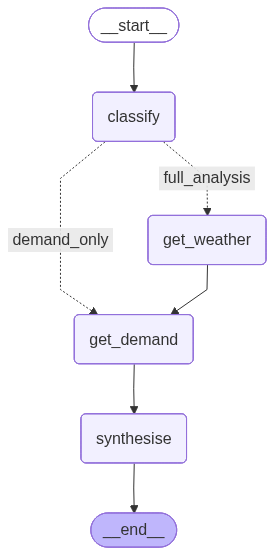

In [21]:
# Draw the workflow graph so the LangGraph control flow is visible.
if LG_AVAILABLE:
    from IPython.display import Image, display
    display(Image(lg_app.get_graph().draw_mermaid_png()))

In [23]:
# Summarise the trade-offs of the three framework options in one table.
FRAMEWORK_TCO = {
    'Python-only': {
        'loc_simple':        30,
        'loc_multi_agent':  400,
        'ext_dependencies':   1,
        'debugging':        'Low (standard Python stack)',
        'multi_agent':      'Manual scaffolding required',
        'observability':    'Manual (print / logging)',
        'learning_curve_d':   0,
        'version_risk':     'None (no framework dependency)',
        'best_for':         'Prototypes, single-step cost-sensitive pipelines',
        'latency_sec':      py_result['latency_sec'],
    },
    'LangChain': {
        'loc_simple':        15,
        'loc_multi_agent':  180,
        'ext_dependencies':   8,
        'debugging':        'Medium-High (abstraction layers)',
        'multi_agent':      'Partial (AgentExecutor)',
        'observability':    'LangSmith (requires account)',
        'learning_curve_d':   3,
        'version_risk':     'High (frequent breaking changes)',
        'best_for':         'RAG pipelines, single-agent tools, rapid prototyping',
        'latency_sec':      round(lc_latency, 2) if lc_latency else 'N/A',
    },
    'LangGraph': {
        'loc_simple':        50,
        'loc_multi_agent':  130,
        'ext_dependencies':   5,
        'debugging':        'Medium (explicit state, step-by-step)',
        'multi_agent':      'First-class (graph-native StateGraph)',
        'observability':    'LangSmith + checkpointing',
        'learning_curve_d':   5,
        'version_risk':     'Medium (stable since v0.2)',
        'best_for':         'Multi-agent systems, human-in-the-loop, complex workflows',
        'latency_sec':      round(lg_latency, 2) if lg_latency else 'N/A',
    },
}

headers = ['Metric'] + list(FRAMEWORK_TCO.keys())
print(f'{headers[0]:<38} {headers[1]:>16} {headers[2]:>16} {headers[3]:>16}')
print('-' * 88)

metrics = [
    'loc_simple', 'loc_multi_agent', 'ext_dependencies',
    'debugging', 'multi_agent', 'learning_curve_d', 'version_risk', 'latency_sec',
]
for m in metrics:
    vals = [str(FRAMEWORK_TCO[fw][m]) for fw in FRAMEWORK_TCO]
    print(f'{m:<38} {vals[0]:>16} {vals[1]:>16} {vals[2]:>16}')

print()
for fw, data in FRAMEWORK_TCO.items():
    print(f'{fw}: {data["best_for"]}')

Metric                                      Python-only        LangChain        LangGraph
----------------------------------------------------------------------------------------
loc_simple                                           30               15               50
loc_multi_agent                                     400              180              130
ext_dependencies                                      1                8                5
debugging                              Low (standard Python stack) Medium-High (abstraction layers) Medium (explicit state, step-by-step)
multi_agent                            Manual scaffolding required Partial (AgentExecutor) First-class (graph-native StateGraph)
learning_curve_d                                      0                3                5
version_risk                           None (no framework dependency) High (frequent breaking changes) Medium (stable since v0.2)
latency_sec                                        9.77         

## Section 4: Build vs Buy Rubric

Build vs Buy is the decision that precedes framework selection.
If the answer is Buy, you are evaluating vendors, not frameworks.

The rubric scores five axes (each 1-3):
- **Differentiation:** Does this component create competitive advantage?
- **Complexity:** How hard is it to build and maintain at scale?
- **Vendor risk:** How much lock-in does buying create?
- **Speed to value:** How fast does buy vs build deliver the first working version?
- **Cost advantage:** Is build cost (engineering time) lower or higher than buy cost (licensing + integration)?

Score >= 11 = **Build** | Score <= 8 = **Buy** | 9-10 = **Buy + Customize**

In [24]:
# Should we build this component ourselves, buy an existing service, or buy one and customize it?

# Score each platform decision with the same simple rubric.
# This makes the Build vs Buy choice more explicit and repeatable.
def build_or_buy(component: str, scores: dict) -> dict:
    # scores: each axis is 1=Buy-favoured, 2=Neutral, 3=Build-favoured
    total = sum(scores.values())
    if total >= 11:
        decision  = 'BUILD'
        rationale = 'Component creates differentiation or vendor risk is too high to accept'
    elif total <= 8:
        decision  = 'BUY'
        rationale = 'Commodity capability; vendor delivers faster and cheaper'
    else:
        decision  = 'BUY + CUSTOMIZE'
        rationale = 'Start with vendor solution, extend where differentiation matters'
    return {
        'component': component, 'scores': scores,
        'total': total, 'decision': decision, 'rationale': rationale,
    }

components = [
    ('Orchestration framework (LangGraph)', {
        'differentiation': 1, 'complexity': 2,
        'vendor_risk': 2,     'speed_advantage': 3, 'cost_advantage': 1,
    }),
    ('RAG vector store (Chroma vs Pinecone)', {
        'differentiation': 1, 'complexity': 3,
        'vendor_risk': 1,     'speed_advantage': 1, 'cost_advantage': 2,
    }),
    ('Walmart domain knowledge base (Q&A dataset)', {
        'differentiation': 3, 'complexity': 1,
        'vendor_risk': 3,     'speed_advantage': 1, 'cost_advantage': 3,
    }),
    ('LLM inference (OpenAI API vs self-hosted)', {
        'differentiation': 1, 'complexity': 3,
        'vendor_risk': 2,     'speed_advantage': 1, 'cost_advantage': 1,
    }),
    ('MCP tool server (FastMCP vs custom HTTP)', {
        'differentiation': 1, 'complexity': 2,
        'vendor_risk': 1,     'speed_advantage': 3, 'cost_advantage': 2,
    }),
]

results = [build_or_buy(name, scores) for name, scores in components]

print(f'{"Component":<48} {"Score":>6} {"Decision":>18}')
print('-' * 74)
for r in results:
    print(f'{r["component"]:<48} {r["total"]:>6} {r["decision"]:>18}')

print()
for r in results:
    print(f'{r["component"]}:')
    print(f'  {r["decision"]}: {r["rationale"]}')

Component                                         Score           Decision
--------------------------------------------------------------------------
Orchestration framework (LangGraph)                   9    BUY + CUSTOMIZE
RAG vector store (Chroma vs Pinecone)                 8                BUY
Walmart domain knowledge base (Q&A dataset)          11              BUILD
LLM inference (OpenAI API vs self-hosted)             8                BUY
MCP tool server (FastMCP vs custom HTTP)              9    BUY + CUSTOMIZE

Orchestration framework (LangGraph):
  BUY + CUSTOMIZE: Start with vendor solution, extend where differentiation matters
RAG vector store (Chroma vs Pinecone):
  BUY: Commodity capability; vendor delivers faster and cheaper
Walmart domain knowledge base (Q&A dataset):
  BUILD: Component creates differentiation or vendor risk is too high to accept
LLM inference (OpenAI API vs self-hosted):
  BUY: Commodity capability; vendor delivers faster and cheaper
MCP tool server (F

In [25]:
# Pull the earlier findings into one recommended production stack for Walmart.
WALMART_RETAIL_ASSISTANT_STACK = {
    'use_case':    'Walmart India Retail Assistant',
    'description': 'AI agent for store associates: inventory, policies, demand planning, supplier queries',
    'scale':       '50,000+ queries/day across 4,700 stores',
    'slo':         'P95 latency < 3s, availability 99.5%, error rate < 1%',
    'protocol': {
        'choice':    'MCP (FastMCP)',
        'rationale': (
            'Standardised tool schema enables reuse across store ops, supply chain, and HR agents '
            'without rewriting tool descriptions. MCP server versioning handles quarterly policy '
            'updates with zero changes to agent code. Demonstrated live in this notebook.'
        ),
    },
    'framework': {
        'choice':    'LangGraph',
        'rationale': (
            'Multi-step workflows (classify -> weather -> demand -> synthesise -> escalate) require '
            'explicit typed state management. LangGraph checkpointing supports human-in-the-loop '
            'for supplier reorder approvals. Demonstrated live with real data in this notebook.'
        ),
    },
    'build_buy': {
        'orchestration':   'Build with LangGraph (open-source, score 9 -- BUY+CUSTOMIZE)',
        'mcp_server':      'Build with FastMCP (score 9 -- BUY+CUSTOMIZE, open-source)',
        'vector_store':    'Buy Pinecone (scale + managed SLA, score 8 -- BUY)',
        'knowledge_base':  'Build internally (Walmart IP, cannot outsource, score 11 -- BUILD)',
        'llm_inference':   'Buy OpenAI API for initial scale; re-evaluate at 100k+ daily queries',
    },
    'evaluation_gate': 'Task Success Rate >= 0.80 on 100-case Walmart golden dataset before production',
}

print('Walmart Retail Assistant -- Recommended Production Stack')
print('=' * 58)
for section, content in WALMART_RETAIL_ASSISTANT_STACK.items():
    if isinstance(content, dict):
        print(f'\n{section.upper()}:')
        for k, v in content.items():
            print(f'  {k}: {v}')
    else:
        print(f'{section}: {content}')

Walmart Retail Assistant -- Recommended Production Stack
use_case: Walmart India Retail Assistant
description: AI agent for store associates: inventory, policies, demand planning, supplier queries
scale: 50,000+ queries/day across 4,700 stores
slo: P95 latency < 3s, availability 99.5%, error rate < 1%

PROTOCOL:
  choice: MCP (FastMCP)
  rationale: Standardised tool schema enables reuse across store ops, supply chain, and HR agents without rewriting tool descriptions. MCP server versioning handles quarterly policy updates with zero changes to agent code. Demonstrated live in this notebook.

FRAMEWORK:
  choice: LangGraph
  rationale: Multi-step workflows (classify -> weather -> demand -> synthesise -> escalate) require explicit typed state management. LangGraph checkpointing supports human-in-the-loop for supplier reorder approvals. Demonstrated live with real data in this notebook.

BUILD_BUY:
  orchestration: Build with LangGraph (open-source, score 9 -- BUY+CUSTOMIZE)
  mcp_server: 

# Happy Learning

In [ ]:
# Agent Design Principles -- Single-Agent vs Multi-Agent